In [1]:
# Run this first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, precision_recall_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("NumPy:", np.__version__, "| Pandas:", pd.__version__)


NumPy: 2.1.3 | Pandas: 2.2.3


---
## Part 1: Build the patient dataset



In [2]:
n = 2000

age = np.random.normal(58, 16, n).clip(18, 95)
num_prior_visits = np.random.poisson(1.2, n)
num_diagnoses = np.random.poisson(3.5, n) + 1
length_of_stay = np.random.gamma(2.0, 2.0, n).clip(1, 30)
systolic_bp = np.random.normal(128, 18, n).clip(85, 200)
heart_rate = np.random.normal(78, 14, n).clip(45, 140)
glucose = np.random.normal(120, 40, n).clip(60, 400)

primary_diagnosis = np.random.choice(
    ["circulatory", "diabetes", "respiratory", "injury", "other"],
    size=n, p=[0.30, 0.20, 0.20, 0.15, 0.15]
)
discharge_disposition = np.random.choice(
    ["home", "home_health", "skilled_nursing", "other"],
    size=n, p=[0.55, 0.20, 0.18, 0.07]
)
insurance = np.random.choice(
    ["medicare", "medicaid", "private", "self_pay"],
    size=n, p=[0.45, 0.20, 0.28, 0.07]
)

df = pd.DataFrame({
    "age": age.round(0),
    "num_prior_visits": num_prior_visits,
    "num_diagnoses": num_diagnoses,
    "length_of_stay": length_of_stay.round(1),
    "systolic_bp": systolic_bp.round(0),
    "heart_rate": heart_rate.round(0),
    "glucose": glucose.round(0),
    "primary_diagnosis": primary_diagnosis,
    "discharge_disposition": discharge_disposition,
    "insurance": insurance,
})

# --- Hidden risk function used ONLY to generate the label (a real dataset wouldn't give you this) ---
risk = (
    -3.2
    + 0.28 * df["num_prior_visits"]
    + 0.18 * (df["num_diagnoses"] - 3.5)
    + 0.05 * (df["age"] - 58) / 16
    + 0.35 * (df["primary_diagnosis"].isin(["circulatory", "diabetes"])).astype(int)
    + 0.30 * (df["discharge_disposition"] == "skilled_nursing").astype(int)
    - 0.25 * (df["discharge_disposition"] == "home").astype(int)
    + 0.015 * (df["glucose"] - 120) / 10
    + 0.10 * (df["length_of_stay"] > 7).astype(int)
    + np.random.normal(0, 0.6, n)  # noise: real patients aren't fully predictable
)
prob_readmit = 1 / (1 + np.exp(-risk))
df["readmitted_30d"] = np.random.binomial(1, prob_readmit)

df.to_csv("readmission_data.csv", index=False)
print("Saved readmission_data.csv with", df.shape[0], "rows and", df.shape[1], "columns.")
df.head()


Saved readmission_data.csv with 2000 rows and 11 columns.


,age,num_prior_visits,num_diagnoses,length_of_stay,systolic_bp,heart_rate,glucose,primary_diagnosis,discharge_disposition,insurance,readmitted_30d
0,66.0,1,3,1.0,152.0,73.0,264.0,injury,home,medicare,0
1,56.0,1,7,3.2,149.0,65.0,122.0,respiratory,home,medicaid,0
2,68.0,2,3,1.4,154.0,80.0,177.0,circulatory,home_health,medicare,1
3,82.0,2,6,2.9,154.0,90.0,161.0,diabetes,home,private,0
4,54.0,0,4,2.6,131.0,73.0,160.0,circulatory,home,medicare,0


### 1.1 First checks — always run these on any new dataset

In [3]:
df = pd.read_csv("readmission_data.csv")
print("Shape:", df.shape)
df.info()


Shape: (2000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    2000 non-null   float64
 1   num_prior_visits       2000 non-null   int64  
 2   num_diagnoses          2000 non-null   int64  
 3   length_of_stay         2000 non-null   float64
 4   systolic_bp            2000 non-null   float64
 5   heart_rate             2000 non-null   float64
 6   glucose                2000 non-null   float64
 7   primary_diagnosis      2000 non-null   object 
 8   discharge_disposition  2000 non-null   object 
 9   insurance              2000 non-null   object 
 10  readmitted_30d         2000 non-null   int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 172.0+ KB


In [4]:
df.describe()


,age,num_prior_visits,num_diagnoses,length_of_stay,systolic_bp,heart_rate,glucose,readmitted_30d
count,2000.000000,2000.00000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000
mean,58.681000,1.17750,4.448500,4.10145,128.461500,78.187500,121.278500,0.080000
std,15.568636,1.06844,1.851503,2.80461,17.833186,13.953412,37.430021,0.271361
min,18.000000,0.00000,1.000000,1.00000,85.000000,45.000000,60.000000,0.000000
25%,48.000000,0.00000,3.000000,2.00000,116.000000,69.000000,93.000000,0.000000
50%,59.000000,1.00000,4.000000,3.40000,129.000000,78.000000,120.000000,0.000000
75%,69.000000,2.00000,6.000000,5.50000,141.000000,88.000000,147.000000,0.000000
max,95.000000,6.00000,13.000000,19.00000,184.000000,133.000000,264.000000,1.000000


In [5]:
readmit_rate = df["readmitted_30d"].mean()
print(f"Overall 30-day readmission rate: {readmit_rate:.1%}")
df["readmitted_30d"].value_counts(normalize=True)


Overall 30-day readmission rate: 8.0%


,proportion
readmitted_30d,
0,0.92
1,0.08


---
## Part 2: Preprocessing and train/test split




In [6]:
numeric_features = ["age", "num_prior_visits", "num_diagnoses", "length_of_stay",
                     "systolic_bp", "heart_rate", "glucose"]
categorical_features = ["primary_diagnosis", "discharge_disposition", "insurance"]

X = df[numeric_features + categorical_features]
y = df["readmitted_30d"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print(f"Train readmit rate: {y_train.mean():.1%} | Test readmit rate: {y_test.mean():.1%}")


Train shape: (1500, 10) | Test shape: (500, 10)
Train readmit rate: 8.0% | Test readmit rate: 8.0%


`stratify=y` keeps the same readmission rate in both the train and test split — important with an imbalanced target like this one.


In [7]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])


---
## Part 3: Logistic regression with L2 regularization




In [8]:
clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]  # predicted probability of readmission

print("Model fitted.")
print(classification_report(y_test, y_pred, target_names=["not readmitted", "readmitted"]))


Model fitted.
                precision    recall  f1-score   support

not readmitted       0.92      1.00      0.96       460
    readmitted       0.00      0.00      0.00        40

      accuracy                           0.92       500
     macro avg       0.46      0.50      0.48       500
  weighted avg       0.85      0.92      0.88       500



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 3.1 What is the model actually learning?




In [9]:
feature_names = (
    numeric_features
    + list(clf.named_steps["preprocess"]
           .named_transformers_["cat"]
           .get_feature_names_out(categorical_features))
)
coefs = clf.named_steps["logreg"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
coef_df = coef_df.sort_values("coefficient", ascending=False)
coef_df


,feature,coefficient
15,discharge_disposition_skilled_nursing,0.361380
7,primary_diagnosis_circulatory,0.283014
2,num_diagnoses,0.249678
0,age,0.206781
17,insurance_medicare,0.193787
10,primary_diagnosis_other,0.135461
13,discharge_disposition_home_health,0.134667
1,num_prior_visits,0.124972
18,insurance_private,0.064978
8,primary_diagnosis_diabetes,0.064263


---
## Part 4: Evaluation — ROC-AUC and the ROC curve

.


Test ROC-AUC: 0.619


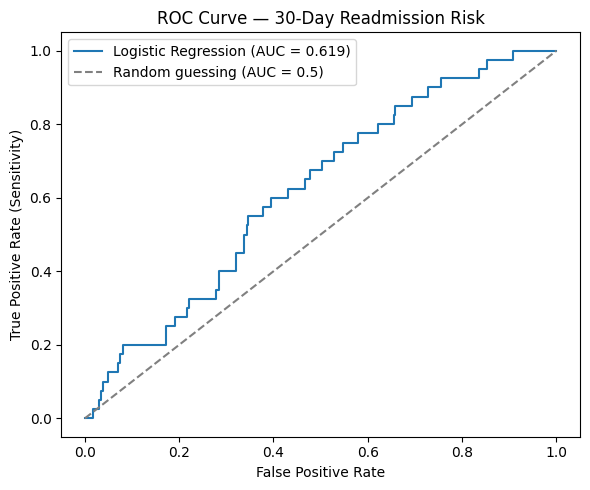

In [10]:
auc = roc_auc_score(y_test, y_proba)
print(f"Test ROC-AUC: {auc:.3f}")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guessing (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve — 30-Day Readmission Risk")
plt.legend()
plt.tight_layout()
plt.show()


### 4.1 Confusion matrix at the default 0.5 threshold


In [11]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual: not readmitted", "Actual: readmitted"],
    columns=["Predicted: not readmitted", "Predicted: readmitted"],
)
cm_df


,Predicted: not readmitted,Predicted: readmitted
Actual: not readmitted,460,0
Actual: readmitted,40,0


---
## Part 5: Clinical cost of false negatives vs. false positives




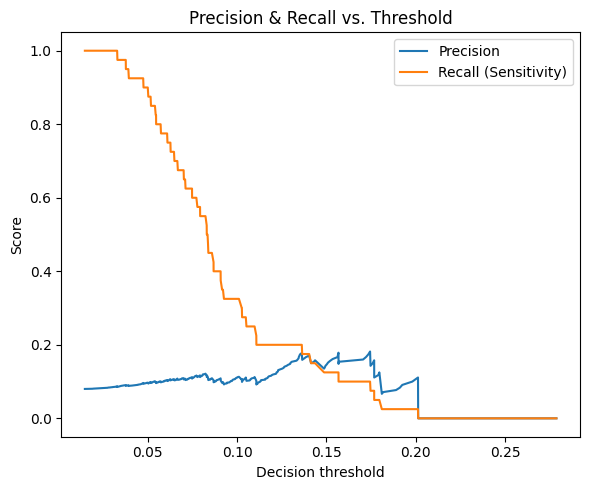

Threshold  0.5: FN= 40  FP=  0  (catches 0/40 = 0% of true readmissions)
Threshold  0.3: FN= 40  FP=  0  (catches 0/40 = 0% of true readmissions)
Threshold  0.2: FN= 39  FP=  8  (catches 1/40 = 2% of true readmissions)


In [12]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(pr_thresholds, precision[:-1], label="Precision")
plt.plot(pr_thresholds, recall[:-1], label="Recall (Sensitivity)")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs. Threshold")
plt.legend()
plt.tight_layout()
plt.show()

# Compare the default threshold to a lowered, more "cautious" threshold
for t in [0.5, 0.3, 0.2]:
    y_pred_t = (y_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    print(f"Threshold {t:>4}: FN={fn:>3}  FP={fp:>3}  "
          f"(catches {tp}/{tp+fn} = {tp/(tp+fn):.0%} of true readmissions)")
